In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('./data/processed/processed_file.csv', encoding='utf-8-sig')

# Первичный осмотр
print(f"📊 Данные: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"📅 Период: {df['Дата заказа'].min()} — {df['Дата заказа'].max()}")
print(f"🏪 Магазины: {df['Магазин'].unique()}")
print(f"📄 Чеков: {df['Файл'].nunique()}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum()}")

📊 Данные: 2517 строк, 10 колонок
📅 Период: 2024-11-15 20:42:46 — 2026-05-22 12:15:39
🏪 Магазины: ['edostavka' 'sosedi']
📄 Чеков: 86

Типы данных:
Магазин                   object
Файл                      object
Дата заказа               object
Товар                     object
Количество               float64
Единица                   object
Вес единицы              float64
Цена за единицу (BYN)    float64
Итого (BYN)              float64
Сумма чека (BYN)         float64
dtype: object

Пропуски:
Магазин                    0
Файл                       0
Дата заказа                0
Товар                      0
Количество                 0
Единица                   67
Вес единицы              116
Цена за единицу (BYN)      0
Итого (BYN)                0
Сумма чека (BYN)           0
dtype: int64


In [123]:
# Конвертация даты

df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])

# Извлечение временных признаков
df['Час'] = df['Дата заказа'].dt.hour
df['День недели'] = df['Дата заказа'].dt.dayofweek  # 0=пн, 6=вс
df['День недели_текст'] = df['Дата заказа'].dt.day_name()
df['Месяц'] = df['Дата заказа'].dt.month
df['Год'] = df['Дата заказа'].dt.year
df['Дата (без времени)'] = df['Дата заказа'].dt.date

# Преобразование веса единицы в число
df['Вес единицы'] = pd.to_numeric(df['Вес единицы'], errors='coerce')

# Категоризация товаров
def categorize_product(product_name):
    """
    Расширенная категоризация товаров с отдельными категориями
    """
    product_name = str(product_name).lower()
    
    # 1. Молочные продукты
    milk_keywords = [
        'молоко', 'йогурт', 'творог', 'сливки', 'кефир', 'сметана', 
        'масло сл', 'сыр', 'ряженка', 'простокваша', 'бифидок', 
        'творожок', 'сырок', 'крем сливоч', 'масло крестьянское',
        'напиток к/м', 'эксп', 'teos', 'здравушка', 'беллакт', 
        'слав.традиции', 'баб.крынка', 'chob', 'parmalat', 'нуво'
    ]
    if any(word in product_name for word in milk_keywords):
        return '🥛 Молочные продукты'
    
    # 2. Мясо и птица
    meat_keywords = [
        'фарш', 'сосиски', 'сардельки', 'голень', 'бекон', 'индейка', 
        'курица', 'цыпленок', 'филе', 'петруха', 'колбаса', 'ветчина', 
        'карбонад', 'грудинка', 'рулет', 'вырезка', 'бройлер', 
        'пельмени', 'вареники', 'котлета', 'биток', 'шницель', 
        'буженина', 'сервелат', 'дзержинка', 'римские', 'троицкие',
        'паляндвица', 'мясн орех', 'охотн', 'кабаносы', 'мортаделла',
        'пражская', 'парма', 'мил.экст', 'биробиджан', 'филейный'
    ]
    if any(word in product_name for word in meat_keywords):
        return '🍖 Мясо/птица'
    
    # 3. Фрукты
    fruit_keywords = [
        'яблоко', 'яблоки', 'банан', 'груша', 'клементин', 'мандарин', 'апельсин', 
        'лимон', 'авокадо', 'хурма', 'манго', 'киви', 'ананас', 'гранат',
        'виноград', 'грейпфрут', 'помело', 'нектарин', 'дыня', 'арбуз',
        'фейхоа', 'слива', 'персик', 'абрикос', 'черешня', 'вишня',
        'малина', 'клубника', 'голубика', 'черника', 'клюква', 'брусника',
        'инжир', 'финики'
    ]
    if any(word in product_name for word in fruit_keywords):
        return '🍎 Фрукты'
    
    # 4. Овощи
    vegetable_keywords = [
        'картофель', 'морковь', 'капуста', 'свекла', 'лук', 'редис', 
        'огурец', 'помидор', 'томат', 'перец', 'баклажан', 'кабачок',
        'тыква', 'редька', 'репа', 'чеснок', 'имбирь', 'сельдерей',
        'петрушка', 'укроп', 'салат', 'айсберг', 'шпинат', 'щавель',
        'грибы', 'шампиньоны', 'вешенки', 'брокколи', 'цветная капуста',
        'спаржа', 'артишок', 'батат', 'редис дайкон', 'топинамбур',
        'пастернак', 'хрен', 'рукола', 'кресс-салат'
    ]
    if any(word in product_name for word in vegetable_keywords):
        return '🥬 Овощи'
    
    # 5. Рыба и морепродукты
    seafood_keywords = [
        'рыба', 'сельдь', 'форель', 'минтай', 'окунь', 'семга', 'лосось',
        'треска', 'щука', 'судак', 'лещ', 'карась', 'карп', 'сом',
        'креветка', 'мидии', 'кальмар', 'осьминог', 'краб', 'матиес',
        'икра', 'бремор', 'морепродукты', 'анчоусы', 'килька', 'шпроты'
    ]
    if any(word in product_name for word in seafood_keywords):
        return '🐟 Рыба/морепродукты'
    
    # 6. СЛАДОСТИ (выделяем отдельно)
    sweets_keywords = [
        'печенье', 'мороженное', 'вафли', 'пряники', 'кекс', 'пирожное', 'торт', 
        'зефир', 'мармелад', 'конфеты', 'шоколад', 'батончики', 
        'вафельный бат', 'маршмеллоу', 'глаз. с арахисом', 'карамель',
        'леденец', 'ирис', 'нуга', 'халва', 'козинак', 'драже',
        'суфле', 'крем', 'десерт', 'чокопай', 'эклер', 'профитроли',
        'слойка', 'сладкая идея', 'витьба by', 'milka', 'спартак', 'merci'
    ]
    if any(word in product_name for word in sweets_keywords):
        return '🍰 Сладости'
    
    # 7. КАШИ И ХЛОПЬЯ (выделяем отдельно)
    cereals_keywords = [
        'каша', 'хлопья', 'готовый зав', 'овсянка', 'геркулес', 'мюсли',
        'крупа', 'рис', 'гречка', 'манка', 'пшено', 'перловка', 'ячка',
        'чечевица', 'горох', 'фасоль', 'киноа', 'булгур', 'кускус'
    ]
    if any(word in product_name for word in cereals_keywords):
        return '🥣 Каши/крупы'
    
    # 8. ХЛЕБ И ХЛЕБОБУЛОЧНЫЕ ИЗДЕЛИЯ (выделяем отдельно)
    bread_keywords = [
        'хлеб', 'батон', 'булка', 'лаваш', 'багет', 'бублик', 'сушки', 
        'баранки', 'рогалик', 'плетенка', 'кирпичик', 'тостовый',
        'чиабатта', 'пита', 'тортилья', 'лепешка', 'сочень', 'калач',
        'кулич', 'пасха', 'кекс домашний'
    ]
    if any(word in product_name for word in bread_keywords):
        return '🍞 Хлеб/выпечка'
    
    # 9. МАКАРОННЫЕ ИЗДЕЛИЯ (отдельно)
    pasta_keywords = [
        'макароны', 'мак.изд', 'паста', 'спагетти', 'вермишель', 
        'лапша', 'рожки', 'перья', 'ракушки', 'спиральки', 'филини',
        'вермичелли', 'маккерони', 'стеллине', 'ризони', 'фузили',
        'пенне', 'барра', 'zara', 'barilla'
    ]
    if any(word in product_name for word in pasta_keywords):
        return '🍝 Макароны'
    
    # 10. НАПИТКИ (кофе, чай, соки и т.д.)
    beverages_keywords = [
        'кофе', 'чай', 'какао', 'сок', 'нектар', 'морс', 'компот', 
        'квас', 'лимонад', 'газировка', 'вода', 'энергетик', 'кола', 
        'спрайт', 'фанта', 'пиво', 'вино', 'шампанское', 'коньяк', 'водка',
        'jardin', 'lavazza', 'illy', 'жокей', 'dallmayr', 'greenfield'
    ]
    if any(word in product_name for word in beverages_keywords):
        return '☕ Напитки'
    
    # 11. ЯЙЦА (отдельно)
    if any(word in product_name for word in ['яйцо', 'яйца']):
        return '🥚 Яйца'
    
    # 12. Детские товары
    baby_keywords = [
        'подгузник', 'памперс', 'трусики', 'пеленка', 'салфетки влаж',
        'бутылочка', 'соска', 'пустышка', 'пюре дет', 'каша дет',
        'смесь молочная', 'непоседа', 'топтышка', 'беллакт дет',
        'watashi', 'senso', 'tanoshi', 'tokisan', 'miu', 'pampers',
        'yumiko', 'омегга', 'деревенское яйцо', 'златко', 'молодец.люкс'
    ]
    if any(word in product_name for word in baby_keywords):
        return '👶 Детские товары'
    
    # 13. Бытовая химия и гигиена
    household_keywords = [
        'бумага туал', 'салфетки', 'полотенце', 'мыло', 'шампунь',
        'гель душ', 'зубная паста', 'щетка', 'прокладка', 'тампон',
        'крем для рук', 'лосьон', 'стиральный порошок', 'кондиционер',
        'средство для мытья', 'чистящее', 'ромакс', 'вела', 'папиа',
        'зипто', 'соффион', 'фэмилиа', 'вейро', 'люксориа', 'арома'
    ]
    if any(word in product_name for word in household_keywords):
        return '🧹 Бытовая химия'
    
    # 14. БАКАЛЕЯ (остальное: соусы, специи, масло, консервы и т.д.)
    grocery_keywords = [
        'мука', 'дрожжи', 'разрыхлитель', 'соль', 'сахар', 'крахмал',
        'кетчуп', 'майонез', 'соус', 'уксус', 'масло раст', 'специи', 
        'приправы', 'варенье', 'джем', 'мед', 'сгущенка', 'конс.мол',
        'сгущ', 'горошек конс', 'кукуруза конс', 'фасоль конс', 
        'оливки', 'маслины', 'консервы', 'паштет', 'тушенка',
        'суп', 'бульон', 'кисель', 'желе', 'пудинг', 'хлебцы', 'сухари',
        'чипсы', 'попкорн', 'снеки', 'орехи', 'семечки', 'суши',
        'эколайн', 'фермер', 'стол.мельница', 'др.бейкерс', 'пряный дом',
        'махеев', 'heinz', 'mikado', 'green ray', 'bonfesto', 'кэнапс'
    ]
    if any(word in product_name for word in grocery_keywords):
        return '🛒 Прочая бакалея'
    
    # 16. Если ничего не подошло
    return product_name

df['Категория'] = df['Товар'].apply(categorize_product)

# -------------------------------------------------------------

# Нормализация количества для весовых товаров (кг/л в граммы/мл)
# 1. По умолчанию копируем исходное количество
df['Вес_норм'] = df['Вес единицы']

# 2. Быстро умножаем на 1000 только там, где единица 'кг' или 'л'
mask = df['Единица'].isin(['кг', 'л'])
df.loc[mask, 'Вес_норм'] = df.loc[mask, 'Вес_норм'] * 1000

# -------------------------------------------------------------

# Агрегация по чеку
cheque_stats = df.groupby('Файл').agg({
    'Итого (BYN)': 'sum',
    'Дата заказа': 'first',
    'Магазин': 'first',
    'Час': 'first',
}).reset_index()
cheque_stats.columns = ['Файл', 'Сумма чека (расч)', 'Дата заказа', 'Магазин', 'Час']
# cheque_stats['Час'] = cheque_stats['Дата заказа'].dt.hour
# cheque_stats['Час'] = pd.to_datetime(cheque_stats['Дата заказа']).dt.hour
cheque_stats['День недели_текст'] = pd.to_datetime(cheque_stats['Дата заказа']).dt.day_name()


print("✅ Предобработка завершена")


# res = cheque_stats[cheque_stats['Файл'] == 'Cheque-1501288055.pdf']
# res


✅ Предобработка завершена


In [124]:
cheque_stats

,Файл,Сумма чека (расч),Дата заказа,Магазин,Час,День недели_текст
0,Check-000001.html,71.32,2026-05-22 12:15:39,sosedi,12,Friday
1,Check-000002.html,263.65,2026-05-19 09:28:56,sosedi,9,Tuesday
2,Check-000003.html,81.95,2026-05-16 10:45:34,sosedi,10,Saturday
3,Check-000004.html,115.23,2026-05-16 11:00:39,sosedi,11,Saturday
4,Check-000005.html,118.41,2026-05-14 11:59:57,sosedi,11,Thursday
...,...,...,...,...,...,...
81,Check-000082.pdf,251.37,2025-04-09 19:04:58,edostavka,19,Wednesday
82,Check-000083.pdf,186.76,2025-04-13 19:22:30,edostavka,19,Sunday
83,Check-000084.pdf,162.96,2025-04-23 20:04:07,edostavka,20,Wednesday
84,Check-000085.pdf,300.71,2025-04-30 21:10:55,edostavka,21,Wednesday


In [125]:
# pd.set_option('display.max_rows', 200)  # Показывать до 200 строк
# pd.set_option('display.max_colwidth', 100)  # Ширина колонки 100 символов

df.sample(n=20)[['Товар', 'Категория']]

,Товар,Категория
1134,Мыло туалетное 100г,🧹 Бытовая химия
802,"Молоко""ЗДРАВУШКА""3.2%(стер,ТБА)1л",🥛 Молочные продукты
33,Рогалик с маком 100г,🍞 Хлеб/выпечка
1880,[М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г,🥛 Молочные продукты
279,"Арахис""НИКИТИН""(жареный)200г","арахис""никитин""(жареный)200г"
1869,"Молоко""ЗДРАВУШКА""3.4- 6%(паст,ПЭТ)0.93 л",🥛 Молочные продукты
1615,Пряники медовые 200г,🍰 Сладости
1541,Кефир 2.5% 0.93л,🥛 Молочные продукты
225,Виноград черный 1кг,🍎 Фрукты
1480,"Масло сл/сл""СЛАВ.ТРАДИЦИИ""82.5%,180г",🥛 Молочные продукты


In [126]:
print("="*60)
print("📊 БАЗОВАЯ СТАТИСТИКА")
print("="*60)

print(f"🛒 Средний чек: {cheque_stats['Сумма чека (расч)'].mean():.2f} BYN")
print(f"📦 Среднее кол-во товаров в чеке: {df.groupby('Файл').size().mean():.1f} шт")

📊 БАЗОВАЯ СТАТИСТИКА
🛒 Средний чек: 233.88 BYN
📦 Среднее кол-во товаров в чеке: 29.3 шт



🏆 ТОП-10 ТОВАРОВ ПО СУММЕ ПОКУПОК
 1. Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л             572.85 BYN
 2. Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л                    450.54 BYN
 3. Масло сл/сл"СЛАВ.ТРАДИЦИИ"82.5%,180г                 348.65 BYN
 4. Творог"ЗДРАВУШКА"9%,200г                             342.41 BYN
 5. Фарш индейка-курица (зам.) 1/500                     301.21 BYN
 6. Сардельки"РИМСКИЕ"(в/с,цб,в/у)390г                   215.43 BYN
 7. [М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г           201.01 BYN
 8. Банан 1кг                                            197.38 BYN
 9. Йогурт"TEOS"2%(греческ,черника)250г                  183.35 BYN
10. Форель охл. (п/с/г,3-4) 3.4-3.6 кг                   174.25 BYN

🏆 ТОП-10 ТОВАРОВ ПО ЧАСТОТЕ ПОКУПОК
 1. Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л            48 раз(а)
 2. Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л                   45 раз(а)
 3. [М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г          37 раз(а)
 4. Банан 1кг                                     

/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 129371 (\N{GLASS OF MILK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 127830 (\N{MEAT ON BONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 127856 (\N{SHORTCAKE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 128031 (\N{FISH}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/742023802.py:35: UserWarning: Glyph 128118 (\N{BABY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_68446/7420238

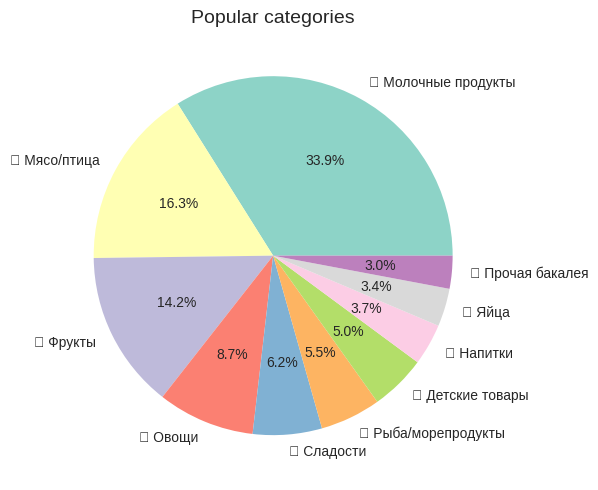

In [127]:
# Топ-10 товаров по сумме
print("\n" + "="*60)
print("🏆 ТОП-10 ТОВАРОВ ПО СУММЕ ПОКУПОК")
print("="*60)
top_products = df.groupby('Товар')['Итого (BYN)'].sum().sort_values(ascending=False).head(10)
for i, (product, total) in enumerate(top_products.items(), 1):
    print(f"{i:2}. {product[:50]:50} {total:8.2f} BYN")

# help(df['Товар'].value_counts)

# Топ-10 товаров по частоте
print("\n" + "="*60)
print("🏆 ТОП-10 ТОВАРОВ ПО ЧАСТОТЕ ПОКУПОК")
print("="*60)
top_frequent = df['Товар'].value_counts().head(10)
for i, (product, count) in enumerate(top_frequent.items(), 1):
    print(f"{i:2}. {product[:50]:50} {count:3} раз(а)")

# По категориям
print("\n" + "="*60)
print("📂 ПОПУЛЯРНОСТЬ КАТЕГОРИЙ")
print("="*60)
category_sum = df.groupby('Категория')['Итого (BYN)'].sum().sort_values(ascending=False).head(10)
category_count = df['Категория'].value_counts()

for cat in category_sum.index:
    print(f"{cat:12} | Сумма: {category_sum[cat]:7.2f} BYN | Кол-во: {category_count[cat]:3} шт | Доля: {category_sum[cat]/df['Итого (BYN)'].sum()*100:.1f}%")


colors = plt.cm.Set3(range(len(category_count)))

plt.figure(figsize=(12, 5))
plt.pie(category_sum, labels=category_sum.index, autopct='%1.1f%%', colors=colors)
plt.title('Popular categories', fontsize=14)
plt.tight_layout()
plt.show()






⏰ АНАЛИЗ ПО ЧАСАМ

📊 По часам:
     Сумма_покупок  Средняя_цена_товара  Кол-во_чеков
Час                                                  
6           952.47                10.03             3
7           953.23                 8.99             3
8          1269.45                 9.27             4
9           540.82                 4.47             3
10          380.16                 4.94             3
11         1341.59                 5.73            10
12          307.63                 4.16             3
15          328.87                 4.57             3
17          464.68                 8.15             2
18         1577.80                 8.26             7
19         3930.53                 8.75            15
20          921.69                 7.49             4
21         2582.77                 9.57             9
22         1459.80                 8.96             5
23         3101.99                 8.91            12


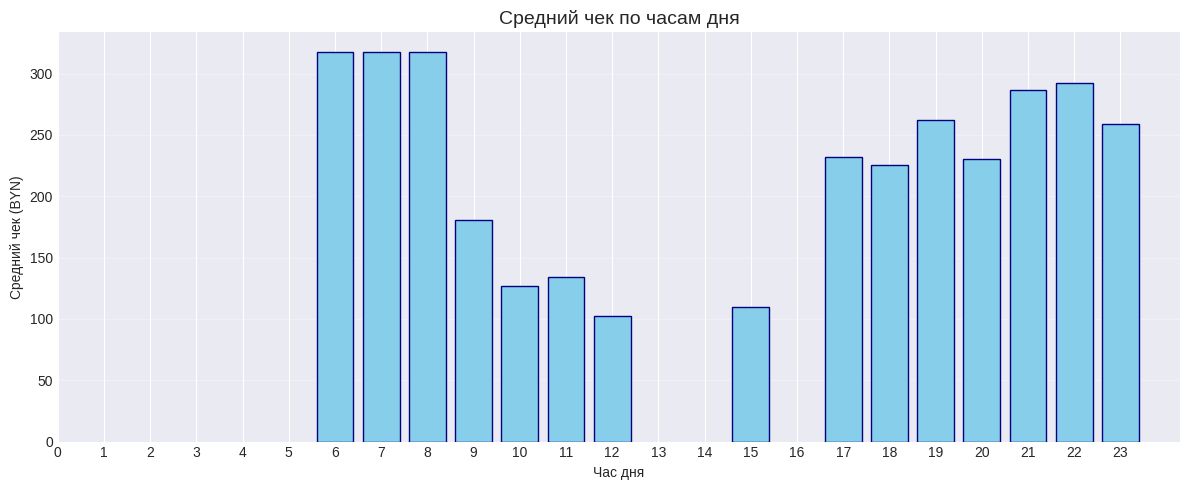


📅 АНАЛИЗ ПО ДНЯМ НЕДЕЛИ
Monday     | Чеков: 12 | Общая сумма: 2248.55 BYN | Средний чек: 187.38 BYN
Tuesday    | Чеков: 15 | Общая сумма: 3870.94 BYN | Средний чек: 258.06 BYN
Wednesday  | Чеков: 11 | Общая сумма: 2740.05 BYN | Средний чек: 249.10 BYN
Thursday   | Чеков: 12 | Общая сумма: 2915.72 BYN | Средний чек: 242.98 BYN
Friday     | Чеков: 14 | Общая сумма: 3345.21 BYN | Средний чек: 238.94 BYN
Saturday   | Чеков: 14 | Общая сумма: 3163.31 BYN | Средний чек: 225.95 BYN
Sunday     | Чеков:  8 | Общая сумма: 1829.70 BYN | Средний чек: 228.71 BYN


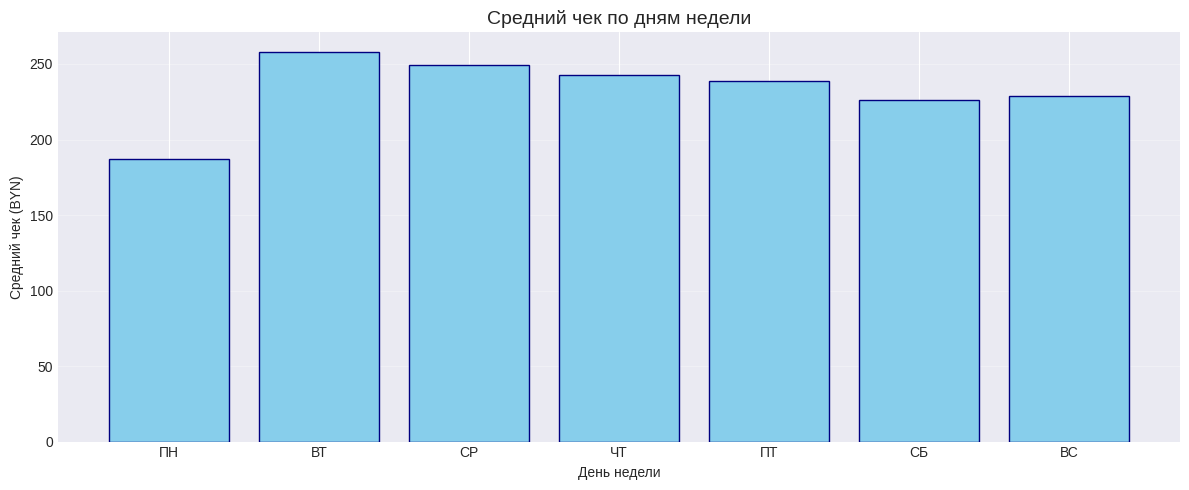

In [128]:
# По часам
print("\n" + "="*60)
print("⏰ АНАЛИЗ ПО ЧАСАМ")
print("="*60)

hourly_stats = df.groupby('Час').agg({
    'Итого (BYN)': ['sum', 'mean'],
    'Файл': 'nunique'
}).round(2)
hourly_stats.columns = ['Сумма_покупок', 'Средняя_цена_товара', 'Кол-во_чеков']

print("\n📊 По часам:")
print(hourly_stats)

# График: средний чек по часам
plt.figure(figsize=(12, 5))
hourly_cheque = cheque_stats.groupby('Час')['Сумма чека (расч)'].mean()
plt.bar(hourly_cheque.index, hourly_cheque.values, color='skyblue', edgecolor='navy')
plt.title('Средний чек по часам дня', fontsize=14)
plt.xlabel('Час дня')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# По дням недели
print("\n" + "="*60)
print("📅 АНАЛИЗ ПО ДНЯМ НЕДЕЛИ")
print("="*60)


days_order_ru = ['ПН', 'ВТ', 'СР', 'ЧТ', 'ПТ', 'СБ', 'ВС']
days_map = {
    'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР',
    'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday': 'ВС'
}

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats = df.groupby('День недели_текст').agg({
    'Итого (BYN)': 'sum',
    'Файл': 'nunique'
}).reindex(days_order)

for day in days_order:
    if day in daily_stats.index:
        avg_cheque = daily_stats.loc[day, 'Итого (BYN)'] / daily_stats.loc[day, 'Файл']
        print(f"{day:10} | Чеков: {daily_stats.loc[day, 'Файл']:2} | Общая сумма: {daily_stats.loc[day, 'Итого (BYN)']:7.2f} BYN | Средний чек: {avg_cheque:.2f} BYN")


# График: средний чек по часам
plt.figure(figsize=(12, 5))
hourly_cheque = cheque_stats.groupby('День недели_текст')['Сумма чека (расч)'].mean()
hourly_cheque_sorted = hourly_cheque.reindex(days_order).rename(days_map)

plt.bar(hourly_cheque_sorted.index, hourly_cheque_sorted.values, color='skyblue', edgecolor='navy')
plt.title('Средний чек по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(0, 7))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()        


🌸 СЕЗОННЫЙ АНАЛИЗ
12
       Итого (BYN)  Файл  Товар
Месяц                          
1          2155.75     8    255
2          1366.23     5    153
3          1926.22    12    282
4          2529.41    13    366
5          2286.47    13    377
6          1173.46     4    140
7          1072.10     4    114
8           951.90     4    109
9          1116.38     4    116
10         1198.82     4    110
11         1807.32     6    201
12         2529.42     9    294


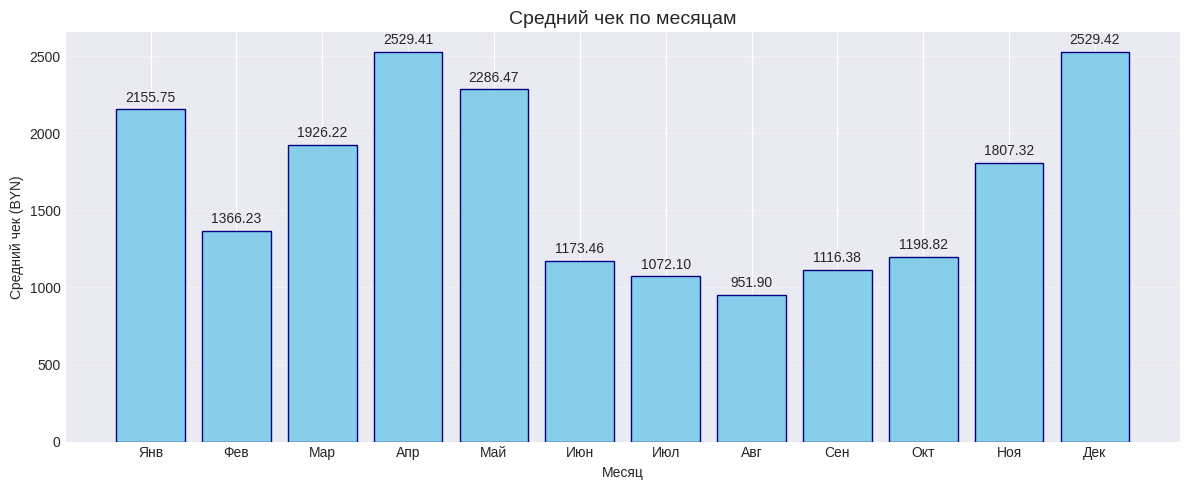

Янв  | Сумма: 2155.75 BYN | Чеков:  8 | Товаров: 255
Фев  | Сумма: 1366.23 BYN | Чеков:  5 | Товаров: 153
Мар  | Сумма: 1926.22 BYN | Чеков: 12 | Товаров: 282
Апр  | Сумма: 2529.41 BYN | Чеков: 13 | Товаров: 366
Май  | Сумма: 2286.47 BYN | Чеков: 13 | Товаров: 377
Июн  | Сумма: 1173.46 BYN | Чеков:  4 | Товаров: 140
Июл  | Сумма: 1072.10 BYN | Чеков:  4 | Товаров: 114
Авг  | Сумма:  951.90 BYN | Чеков:  4 | Товаров: 109
Сен  | Сумма: 1116.38 BYN | Чеков:  4 | Товаров: 116
Окт  | Сумма: 1198.82 BYN | Чеков:  4 | Товаров: 110
Ноя  | Сумма: 1807.32 BYN | Чеков:  6 | Товаров: 201
Дек  | Сумма: 2529.42 BYN | Чеков:  9 | Товаров: 294


In [129]:
print("\n" + "="*60)
print("🌸 СЕЗОННЫЙ АНАЛИЗ")
print("="*60)

# Месячная динамика
monthly = df.groupby('Месяц').agg({
    'Итого (BYN)': 'sum',
    'Файл': 'nunique',
    'Товар': 'count'
})

print(len(monthly))
print(monthly.head(n=20))

months_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

plt.figure(figsize=(12, 5))
plt.bar(monthly.index, monthly['Итого (BYN)'], color='skyblue', edgecolor='navy')
plt.title('Средний чек по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(1, len(monthly)+1), months_names)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Добавляем значения на столбцы
for i, value in enumerate(monthly['Итого (BYN)']):
    plt.text(i + 1, value + 50, f'{value:.2f}', ha='center', fontsize=10)
plt.show()


for month in monthly.index:
    if month <= len(months_names):
        print(f"{months_names[month-1]:4} | Сумма: {monthly.loc[month, 'Итого (BYN)']:7.2f} BYN | Чеков: {monthly.loc[month, 'Файл']:2} | Товаров: {monthly.loc[month, 'Товар']:2}")



# Сезонные товары (появляются только в определённые месяцы)
# print("\n🍓 ПОТЕНЦИАЛЬНО СЕЗОННЫЕ ТОВАРЫ:")
# seasonal_candidates = ['клементин', 'грейпфрут', 'мандарин', 'арбуз', 'клубника']
# for candidate in seasonal_candidates:
#     mask = df['Товар'].str.lower().str.contains(candidate, na=False)
#     if mask.any():
#         months_found = df[mask]['Месяц'].unique()
#         print(f"   {candidate}: встречается в месяцах {sorted(months_found)}")

In [130]:
print("\n" + "="*60)
print("🔄 ПОСТОЯННЫЕ ПОКУПКИ (в >40% чеков)")
print("="*60)

total_cheques = df['Файл'].nunique()
product_frequency = df.groupby('Товар')['Файл'].nunique().sort_values(ascending=False)
constant_products = product_frequency[product_frequency / total_cheques > 0.4]

# print("\n" + "="*60)
# print(product_frequency)
# print("="*60)
# product_frequency = df.groupby('Товар')['Файл'].nunique().sort_values(ascending=False).reset_index().set_index('Товар')
# print("\n" + "="*60)
# print(product_frequency)
# print("="*60)
# print("\n" + "="*60)
# print(product_frequency.squeeze())
# print("="*60)
# product_frequency = product_frequency.squeeze()
# constant_products = product_frequency[product_frequency / total_cheques > 0.4]


for product, freq in constant_products.head(10).items():
    percentage = (freq / total_cheques) * 100
    print(f"   {product[:45]:45} | {percentage:.0f}% чеков ({freq}/{total_cheques})")


🔄 ПОСТОЯННЫЕ ПОКУПКИ (в >40% чеков)
   Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л      | 56% чеков (48/86)
   Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л             | 52% чеков (45/86)


In [131]:
print("\n" + "="*60)
print("📈 ДИНАМИКА ЦЕН (повторяющиеся товары)")
print("="*60)

# Находим товары, которые покупались минимум 2 раза
product_counts = df.groupby('Товар').size()

# it will work more slowly
# product_counts = df.groupby('Товар').apply(len)

repeated_products = product_counts[product_counts >= 2].sort_values(ascending=False).index

for product in repeated_products[:10]:  # топ-5 для примера
    product_data = df[df['Товар'] == product].sort_values('Дата заказа')
    if len(product_data) >= 2:
        print(f"\n📊 {product[:50]}:")
        for _, row in product_data.iterrows():
            print(f"   {row['Дата заказа'].strftime('%Y-%m-%d')}: {row['Цена за единицу (BYN)']:.2f} BYN за {row['Вес единицы']} {row['Единица']}")


📈 ДИНАМИКА ЦЕН (повторяющиеся товары)

📊 Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л:
   2024-11-29: 2.71 BYN за 0.93 л
   2024-12-06: 2.60 BYN за 0.93 л
   2024-12-17: 2.60 BYN за 0.93 л
   2024-12-28: 2.60 BYN за 0.93 л
   2025-01-04: 2.60 BYN за 0.93 л
   2025-01-09: 2.60 BYN за 0.93 л
   2025-01-14: 2.60 BYN за 0.93 л
   2025-01-25: 2.60 BYN за 0.93 л
   2025-04-01: 2.86 BYN за 0.93 л
   2025-04-09: 2.86 BYN за 0.93 л
   2025-04-13: 2.86 BYN за 0.93 л
   2025-04-23: 2.86 BYN за 0.93 л
   2025-04-30: 2.91 BYN за 0.93 л
   2025-05-04: 2.92 BYN за 0.93 л
   2025-05-16: 2.92 BYN за 0.93 л
   2025-05-22: 2.92 BYN за 0.93 л
   2025-06-05: 2.92 BYN за 0.93 л
   2025-06-12: 3.10 BYN за 0.93 л
   2025-06-18: 3.10 BYN за 0.93 л
   2025-06-26: 3.10 BYN за 0.93 л
   2025-07-15: 3.10 BYN за 0.93 л
   2025-07-24: 3.10 BYN за 0.93 л
   2025-07-30: 3.10 BYN за 0.93 л
   2025-08-02: 3.12 BYN за 0.93 л
   2025-08-13: 3.12 BYN за 0.93 л
   2025-08-18: 3.12 BYN за 0.93 л
   2025-08-26: 3.12 BYN за 0.93 


📈 ДИНАМИКА ЦЕН (повторяющиеся товары)


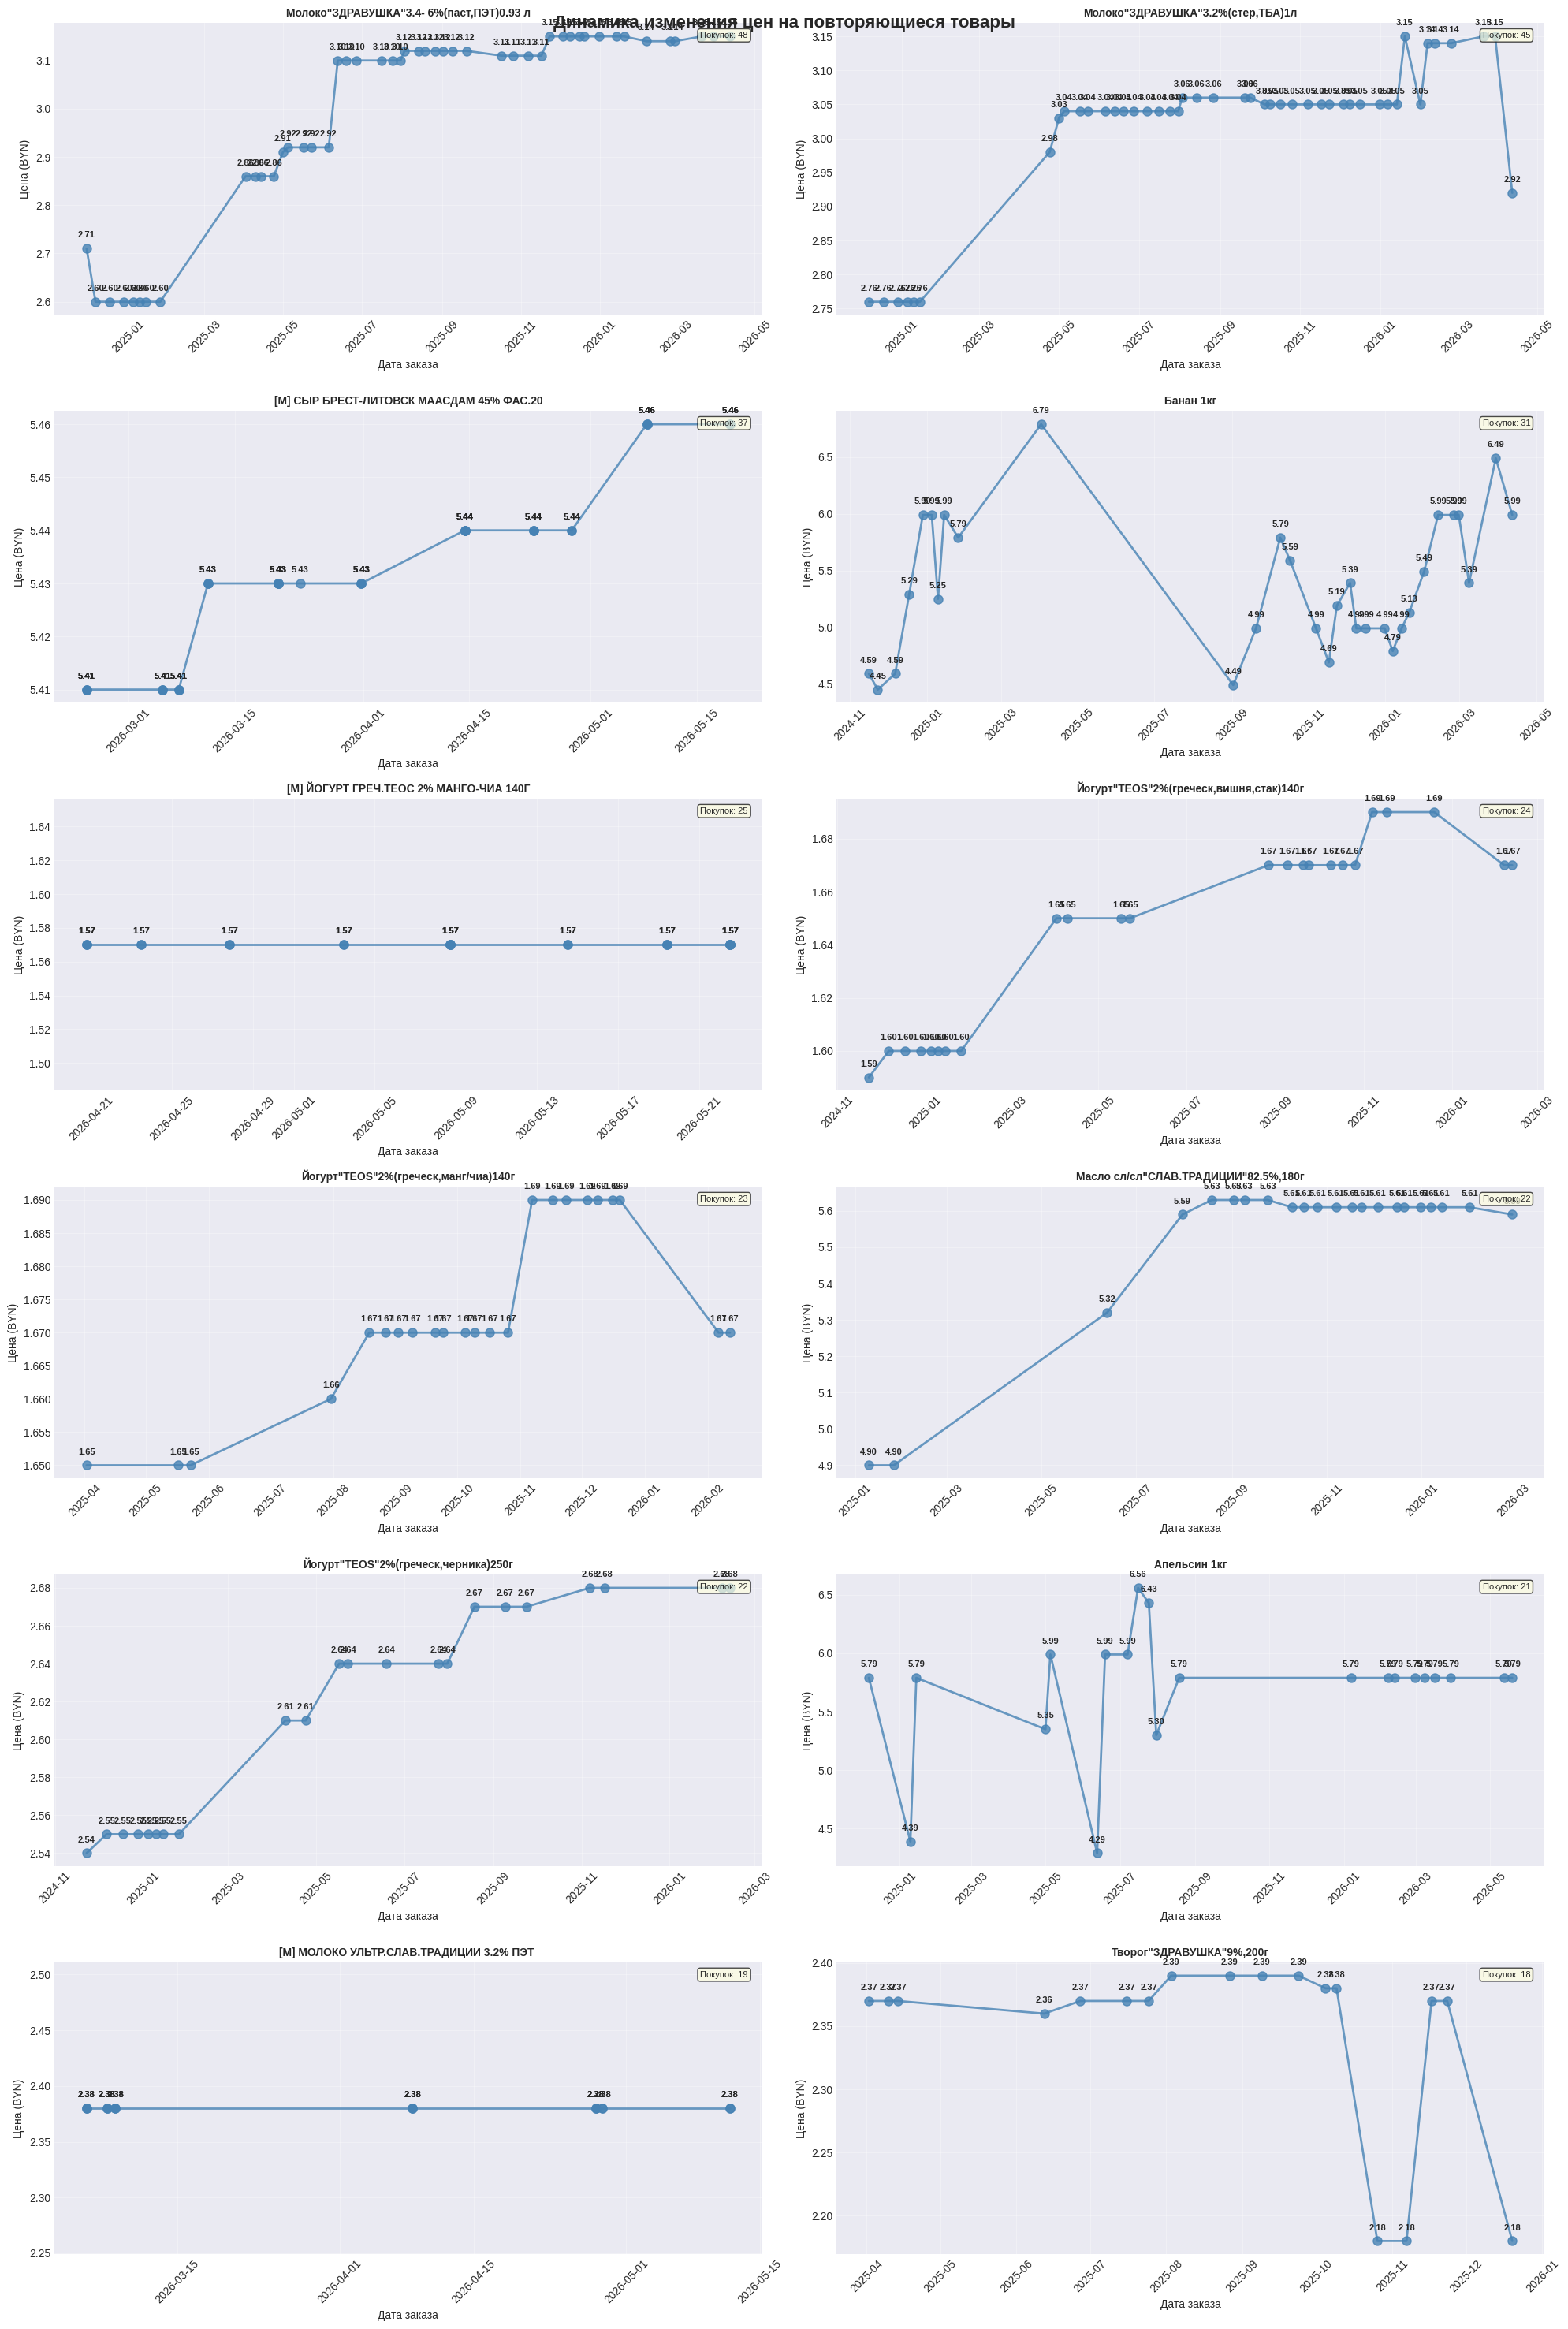

In [132]:
import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "="*60)
print("📈 ДИНАМИКА ЦЕН (повторяющиеся товары)")
print("="*60)

# Находим товары, которые покупались минимум 2 раза
product_counts = df.groupby('Товар').size()
repeated_products = product_counts[product_counts >= 2].sort_values(ascending=False).index

# Настройка графиков - по 4 в строку
n_products = min(12, len(repeated_products))  # 12 товаров = 3 строки по 4
n_rows = (n_products + 1) // 2  # округление вверх для 4 колонок
fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows))  # 4 колонки
axes = axes.flatten()

for idx, product in enumerate(repeated_products[:n_products]):
    product_data = df[df['Товар'] == product].sort_values('Дата заказа')
    
    if len(product_data) >= 2:
        ax = axes[idx]
        
        # Преобразуем даты в формат для графика
        dates = pd.to_datetime(product_data['Дата заказа'])
        prices = product_data['Цена за единицу (BYN)']
        
        # Строим линию с маркерами
        ax.plot(dates, prices, marker='o', linewidth=2, 
                markersize=8, color='steelblue', linestyle='-', alpha=0.8)
        
        # Добавляем значения на точки
        for i, (date, price) in enumerate(zip(dates, prices)):
            ax.annotate(f'{price:.2f}', 
                       xy=(date, price), 
                       xytext=(0, 10), 
                       textcoords='offset points',
                       ha='center', fontsize=8, fontweight='bold')
        
        # Оформление
        ax.set_title(f'{product[:40]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Дата заказа')
        ax.set_ylabel('Цена (BYN)')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Добавляем информацию о количестве покупок
        ax.text(0.98, 0.95, f'Покупок: {len(product_data)}', 
                transform=ax.transAxes, ha='right', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Скрываем лишние подграфики
for idx in range(n_products, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Динамика изменения цен на повторяющиеся товары', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("📈 АНАЛИЗ ПОДОРОЖАНИЯ ТОВАРОВ")
print("="*60)

# Находим товары с минимум 2 покупками
product_counts = df.groupby('Товар').size()
repeated_products = product_counts[product_counts >= 2].sort_values(ascending=False).index

# Собираем данные о динамике цен
price_analysis = []

for product in repeated_products:
    product_data = df[df['Товар'] == product].sort_values('Дата заказа')
    
    if len(product_data) >= 2:
        first_price = product_data['Цена за единицу (BYN)'].iloc[0]
        last_price = product_data['Цена за единицу (BYN)'].iloc[-1]
        first_date = product_data['Дата заказа'].iloc[0]
        last_date = product_data['Дата заказа'].iloc[-1]
        
        # Абсолютное изменение
        abs_change = last_price - first_price
        # Относительное изменение (%)
        rel_change = (last_price - first_price) / first_price * 100
        
        price_analysis.append({
            'Товар': product,
            'Первая цена': first_price,
            'Последняя цена': last_price,
            'Изменение (BYN)': abs_change,
            'Изменение (%)': rel_change,
            'Первая дата': first_date,
            'Последняя дата': last_date,
            'Кол-во покупок': len(product_data)
        })

# Создаем DataFrame для анализа
price_df = pd.DataFrame(price_analysis)

# Сортируем по относительному изменению (убывание)
price_df = price_df.sort_values('Изменение (%)', ascending=False)

# Выводим топ-20 подорожавших товаров
print("\n🔝 ТОП-20 САМЫХ ПОДОРОЖАВШИХ ТОВАРОВ:")
print("-" * 70)
for _, row in price_df.head(20).iterrows():
    icon = "🚀" if row['Изменение (%)'] > 20 else "📈" if row['Изменение (%)'] > 10 else "📊"
    print(f"{icon} {row['Товар'][:45]:45} | {row['Изменение (%)']:+.1f}% "
          f"({row['Первая цена']:.2f} → {row['Последняя цена']:.2f} BYN)")

# Выводим топ-20 подешевевших товаров
print("\n📉 ТОП-20 САМЫХ ПОДЕШЕВЕВШИХ ТОВАРОВ:")
print("-" * 70)
for _, row in price_df.tail(20).sort_values('Изменение (%)').head(20).iterrows():
    print(f"📉 {row['Товар'][:45]:45} | {row['Изменение (%)']:+.1f}% "
          f"({row['Первая цена']:.2f} → {row['Последняя цена']:.2f} BYN)")

# Статистика
print("\n" + "="*60)
print("📊 СТАТИСТИКА ПО ВСЕМ ТОВАРАМ:")
print(f"   Всего проанализировано товаров: {len(price_df)}")
print(f"   Среднее изменение (%): {price_df['Изменение (%)'].mean():+.1f}%")
print(f"   Медианное изменение (%): {price_df['Изменение (%)'].median():+.1f}%")
print(f"   Максимальное подорожание: {price_df['Изменение (%)'].max():+.1f}%")
print(f"   Максимальное удешевление: {price_df['Изменение (%)'].min():+.1f}%")


📈 АНАЛИЗ ПОДОРОЖАНИЯ ТОВАРОВ

🔝 ТОП-20 САМЫХ ПОДОРОЖАВШИХ ТОВАРОВ:
----------------------------------------------------------------------
🚀 Морковь мытая (пакет)1кг                      | +100.6% (1.69 → 3.39 BYN)
🚀 Картофель (мытый)1кг                          | +60.2% (2.49 → 3.99 BYN)
🚀 Томат (Беларусь)1кг                           | +57.8% (4.79 → 7.56 BYN)
🚀 Вареники"БАБУШКА АНЯ"(с творогом)430г         | +53.5% (3.29 → 5.05 BYN)
🚀 Груша красная"КОМИС"1кг                       | +50.1% (4.55 → 6.83 BYN)
🚀 Лимон 1кг                                     | +50.1% (5.99 → 8.99 BYN)
🚀 Авокадо Хасс 1кг                              | +50.1% (9.99 → 14.99 BYN)
🚀 Туалетная бумага «Zeno Premium» трехслойная,  | +49.6% (5.73 → 8.57 BYN)
🚀 Подгузники-трусики детские, впитывающие "TOKI | +48.0% (19.99 → 29.59 BYN)
🚀 Бумага туал."PAPIA"(балий.цвет,3сл)8рул       | +43.2% (8.78 → 12.57 BYN)
🚀 Салат"АЙСБЕРГ"1кг                             | +42.3% (8.99 → 12.79 BYN)
🚀 Зефир жев."ПУХЛЫЙ КРОЛИК"(Bu

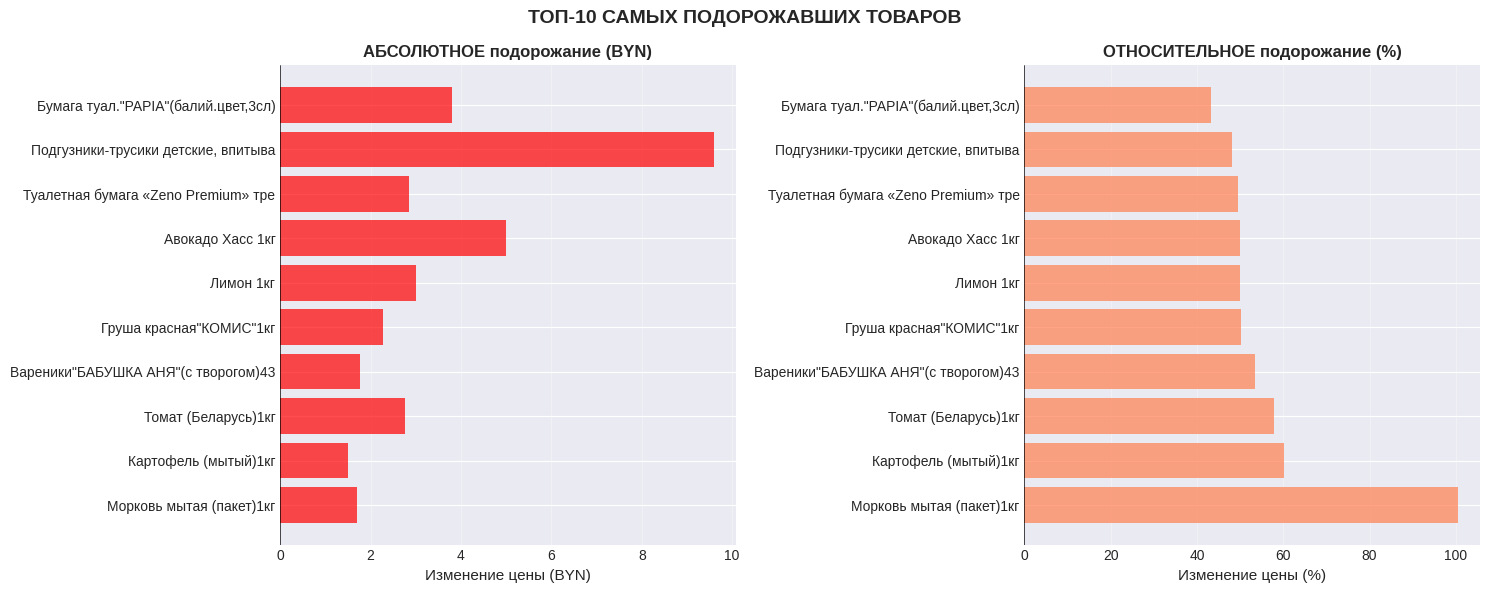

In [134]:
# График топ-10 подорожавших товаров
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Абсолютное изменение
top_expensive = price_df.head(10)
colors = ['red' if x > 0 else 'green' for x in top_expensive['Изменение (BYN)']]
axes[0].barh(range(len(top_expensive)), top_expensive['Изменение (BYN)'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_expensive)))
axes[0].set_yticklabels([p[:35] for p in top_expensive['Товар']])
axes[0].set_xlabel('Изменение цены (BYN)', fontsize=11)
axes[0].set_title('АБСОЛЮТНОЕ подорожание (BYN)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)

# График 2: Относительное изменение
axes[1].barh(range(len(top_expensive)), top_expensive['Изменение (%)'], color='coral', alpha=0.7)
axes[1].set_yticks(range(len(top_expensive)))
axes[1].set_yticklabels([p[:35] for p in top_expensive['Товар']])
axes[1].set_xlabel('Изменение цены (%)', fontsize=11)
axes[1].set_title('ОТНОСИТЕЛЬНОЕ подорожание (%)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('ТОП-10 САМЫХ ПОДОРОЖАВШИХ ТОВАРОВ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [135]:
# Анализ с учетом периода между покупками
price_df['Период (дней)'] = (pd.to_datetime(price_df['Последняя дата']) - 
                              pd.to_datetime(price_df['Первая дата'])).dt.days
price_df['Изменение в день (BYN)'] = price_df['Изменение (BYN)'] / price_df['Период (дней)']

# Топ по скорости подорожания
fastest_increase = price_df.nlargest(10, 'Изменение в день (BYN)')

print("\n⚡ ТОП-10 ПО СКОРОСТИ ПОДОРОЖАНИЯ (BYN/день):")
print("-" * 70)
for _, row in fastest_increase.iterrows():
    print(f"   {row['Товар'][:45]:45} | {row['Изменение в день (BYN)']:.3f} BYN/день "
          f"(за {row['Период (дней)']} дней)")

# Инфляционный индекс (сколько товаров подорожало vs подешевело)
price_increased = len(price_df[price_df['Изменение (%)'] > 0])
price_decreased = len(price_df[price_df['Изменение (%)'] < 0])
price_unchanged = len(price_df[price_df['Изменение (%)'] == 0])

print("\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"   📈 Подорожало: {price_increased} товаров ({price_increased/len(price_df)*100:.1f}%)")
print(f"   📉 Подешевело: {price_decreased} товаров ({price_decreased/len(price_df)*100:.1f}%)")
print(f"   ➖ Без изменений: {price_unchanged} товаров")


⚡ ТОП-10 ПО СКОРОСТИ ПОДОРОЖАНИЯ (BYN/день):
----------------------------------------------------------------------
   Подгузники-трусики детские, впитывающие "MIU" | 0.078 BYN/день (за 32 дней)
   Огурец гладкий (45+)1кг                       | 0.069 BYN/день (за 21 дней)
   Перец красный "ПОРТЕКО" 1 кг                  | 0.067 BYN/день (за 19 дней)
   Мандарин (бейби) Китай 1кг                    | 0.067 BYN/день (за 6 дней)
   ШАРИКИ ВИТЬБА ШОКОЛАДНЫЕ 250Г                 | 0.062 BYN/день (за 8 дней)
   Наб.конфет "MERCI"(ассорти мол.шок)250г       | 0.058 BYN/день (за 24 дней)
   Баклажан грунтовой 1 кг                       | 0.053 BYN/день (за 15 дней)
   Подгузники-трусики детские, впитывающие "MIU" | 0.052 BYN/день (за 46 дней)
   Манго зрелое 1кг                              | 0.052 BYN/день (за 58 дней)
   Апельсин ЕГИПЕТ 1 кг                          | 0.049 BYN/день (за 7 дней)

📊 ОБЩАЯ СТАТИСТИКА:
   📈 Подорожало: 137 товаров (31.2%)
   📉 Подешевело: 54 товаров (12.3%)
  


🏆 САМЫЙ ПОДОРОЖАВШИЙ ТОВАР:

📦 Товар: Морковь мытая (пакет)1кг
📅 Период: 17.12.2024 → 28.02.2026
💰 Цена была: 1.69 BYN
💰 Цена стала: 3.39 BYN
📈 Изменение: +1.70 BYN (+100.6%)
🔄 Количество покупок: 7


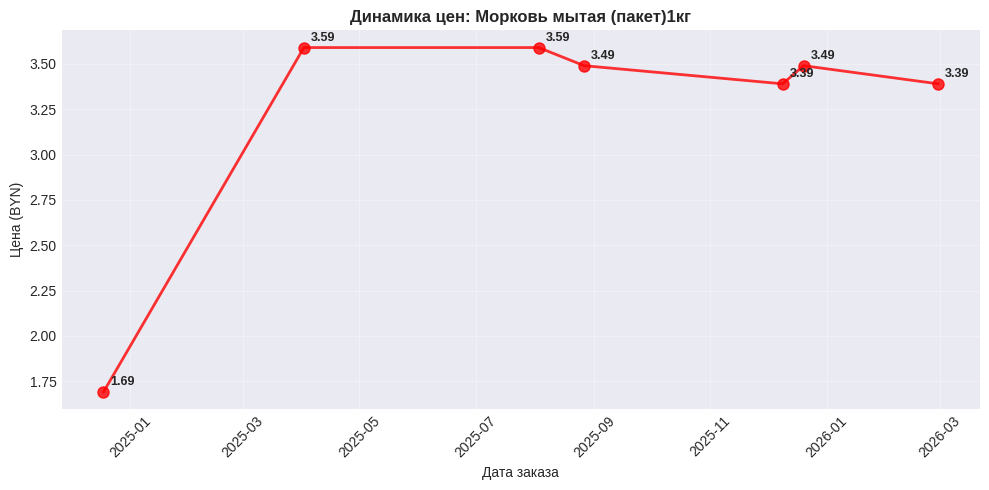

In [136]:
# Находим самый подорожавший товар
top_product = price_df.iloc[0]

print("\n" + "="*60)
print("🏆 САМЫЙ ПОДОРОЖАВШИЙ ТОВАР:")
print("="*60)
print(f"\n📦 Товар: {top_product['Товар']}")
print(f"📅 Период: {top_product['Первая дата'].strftime('%d.%m.%Y')} → "
      f"{top_product['Последняя дата'].strftime('%d.%m.%Y')}")
print(f"💰 Цена была: {top_product['Первая цена']:.2f} BYN")
print(f"💰 Цена стала: {top_product['Последняя цена']:.2f} BYN")
print(f"📈 Изменение: +{top_product['Изменение (BYN)']:.2f} BYN (+{top_product['Изменение (%)']:.1f}%)")
print(f"🔄 Количество покупок: {top_product['Кол-во покупок']}")

# Детальная динамика самого подорожавшего товара
product_data = df[df['Товар'] == top_product['Товар']].sort_values('Дата заказа')

plt.figure(figsize=(10, 5))
dates = pd.to_datetime(product_data['Дата заказа'])
prices = product_data['Цена за единицу (BYN)']

plt.plot(dates, prices, marker='o', linewidth=2, markersize=8, 
         color='red', linestyle='-', alpha=0.8)

# Добавляем значения
for i, (date, price) in enumerate(zip(dates, prices)):
    plt.annotate(f'{price:.2f}', 
                xy=(date, price), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.title(f'Динамика цен: {top_product["Товар"][:60]}', fontsize=12, fontweight='bold')
plt.xlabel('Дата заказа')
plt.ylabel('Цена (BYN)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def compare_shops_monthly(df):
    """
    Сравнительный анализ магазинов по месяцам
    """
    # Преобразуем дату
    df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])
    
    # Агрегируем по чеку (один чек = один файл)
    cheque_agg = df.groupby(['Файл', 'Магазин']).agg({
        'Дата заказа': 'first',
        'Итого (BYN)': 'sum'
    }).reset_index()
    
    # Извлекаем месяц и год
    cheque_agg['Год-месяц'] = cheque_agg['Дата заказа'].dt.to_period('M')
    cheque_agg['Месяц'] = cheque_agg['Дата заказа'].dt.strftime('%Y-%m')
    
    # Группируем по магазину и месяцу
    monthly_stats = cheque_agg.groupby(['Магазин', 'Год-месяц', 'Месяц']).agg({
        'Итого (BYN)': ['sum', 'mean', 'count'],
        'Файл': 'count'
    }).round(2)
    
    # Переименовываем колонки
    monthly_stats.columns = ['Сумма_чеков', 'Средний_чек', 'Количество_чеков', 'Количество_чеков2']
    monthly_stats = monthly_stats.drop('Количество_чеков2', axis=1)
    monthly_stats = monthly_stats.reset_index()
    
    # Сортируем по дате
    monthly_stats = monthly_stats.sort_values('Год-месяц')
    
    # ========== ГРАФИК 1: Сумма чеков по месяцам ==========
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Сравнительный анализ магазинов', fontsize=16, fontweight='bold')
    
    # 1. Сумма чеков по месяцам (линейный график)
    for shop in monthly_stats['Магазин'].unique():
        shop_data = monthly_stats[monthly_stats['Магазин'] == shop]
        axes[0,0].plot(shop_data['Месяц'], shop_data['Сумма_чеков'], 
                      marker='o', linewidth=2, markersize=8, label=shop)
    
    axes[0,0].set_title('Сумма чеков по месяцам', fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('Месяц', fontsize=10)
    axes[0,0].set_ylabel('Сумма чеков (BYN)', fontsize=10)
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Сумма чеков по месяцам (столбчатая диаграмма)
    x = range(len(monthly_stats['Месяц'].unique()))
    width = 0.35
    
    shops = monthly_stats['Магазин'].unique()
    colors = {'edostavka': '#3498db', 'соседи': '#e74c3c'}
    
    for i, shop in enumerate(shops):
        shop_data = monthly_stats[monthly_stats['Магазин'] == shop]
        # Создаем полный массив данных для всех месяцев
        all_months = monthly_stats['Месяц'].unique()
        shop_values = []
        for month in all_months:
            val = shop_data[shop_data['Месяц'] == month]['Сумма_чеков'].values
            shop_values.append(val[0] if len(val) > 0 else 0)
        
        offset = (i - 0.5) * width
        axes[0,1].bar([j + offset for j in x], shop_values, width, 
                     label=shop, color=colors.get(shop, '#95a5a6'), alpha=0.8)
    
    axes[0,1].set_title('Сумма чеков по месяцам (сравнение)', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Месяц', fontsize=10)
    axes[0,1].set_ylabel('Сумма чеков (BYN)', fontsize=10)
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(monthly_stats['Месяц'].unique(), rotation=45)
    axes[0,1].legend()
    axes[0,1].grid(axis='y', alpha=0.3)
    
    # 3. Средний чек по месяцам
    for shop in monthly_stats['Магазин'].unique():
        shop_data = monthly_stats[monthly_stats['Магазин'] == shop]
        axes[1,0].plot(shop_data['Месяц'], shop_data['Средний_чек'], 
                      marker='s', linewidth=2, markersize=8, label=shop)
    
    axes[1,0].set_title('Средний чек по месяцам', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Месяц', fontsize=10)
    axes[1,0].set_ylabel('Средний чек (BYN)', fontsize=10)
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Количество чеков по месяцам
    for shop in monthly_stats['Магазин'].unique():
        shop_data = monthly_stats[monthly_stats['Магазин'] == shop]
        axes[1,1].bar(shop_data['Месяц'], shop_data['Количество_чеков'], 
                     label=shop, alpha=0.7, color=colors.get(shop, '#95a5a6'))
    
    axes[1,1].set_title('Количество чеков по месяцам', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Месяц', fontsize=10)
    axes[1,1].set_ylabel('Количество чеков', fontsize=10)
    axes[1,1].legend()
    axes[1,1].grid(axis='y', alpha=0.3)
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # ========== ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ==========
    
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle('Общая статистика по магазинам', fontsize=16, fontweight='bold')
    
    # Общая статистика по магазинам
    total_stats = df.groupby('Магазин').agg({
        'Итого (BYN)': ['sum', 'mean', 'count'],
        'Файл': 'nunique'
    }).round(2)
    total_stats.columns = ['Общая_выручка', 'Средний_чек', 'Количество_товаров', 'Количество_чеков']
    total_stats = total_stats.reset_index()
    
    # 1. Общая выручка по магазинам (круговая диаграмма)
    colors_circle = ['#3498db', '#e74c3c']
    axes2[0].pie(total_stats['Общая_выручка'], labels=total_stats['Магазин'], 
                autopct='%1.1f%%', colors=colors_circle, startangle=90,
                explode=(0.05, 0.05), shadow=True)
    axes2[0].set_title(f'Доля в общей выручке\nВсего: {total_stats["Общая_выручка"].sum():.2f} BYN', 
                      fontsize=12, fontweight='bold')
    
    # 2. Сравнение среднего чека (столбчатая диаграмма)
    bars = axes2[1].bar(total_stats['Магазин'], total_stats['Средний_чек'], 
                       color=colors_circle, edgecolor='black', alpha=0.8)
    axes2[1].set_title('Сравнение среднего чека', fontsize=12, fontweight='bold')
    axes2[1].set_xlabel('Магазин', fontsize=10)
    axes2[1].set_ylabel('Средний чек (BYN)', fontsize=10)
    axes2[1].grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, total_stats['Средний_чек']):
        axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{value:.2f}', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ========== ВЫВОД СТАТИСТИКИ ==========
    
    print("\n" + "="*60)
    print("📊 СРАВНИТЕЛЬНАЯ СТАТИСТИКА ПО МАГАЗИНАМ")
    print("="*60)
    
    for _, row in total_stats.iterrows():
        print(f"\n🏪 {row['Магазин'].upper()}:")
        print(f"   • Общая выручка: {row['Общая_выручка']:.2f} BYN")
        print(f"   • Средний чек: {row['Средний_чек']:.2f} BYN")
        print(f"   • Количество чеков: {int(row['Количество_чеков'])}")
        print(f"   • Количество товаров: {int(row['Количество_товаров'])}")
        print(f"   • Среднее кол-во товаров в чеке: {row['Количество_товаров']/row['Количество_чеков']:.1f}")
    
    print("\n" + "="*60)
    print("📅 ПОМЕСЯЧНАЯ СТАТИСТИКА")
    print("="*60)
    
    # Сводная таблица по месяцам
    pivot_table = monthly_stats.pivot_table(
        index='Месяц', 
        columns='Магазин', 
        values='Сумма_чеков',
        fill_value=0
    )
    
    print("\nСумма чеков по месяцам (BYN):")
    print(pivot_table.to_string())
    
    # Добавляем средний чек
    pivot_avg = monthly_stats.pivot_table(
        index='Месяц', 
        columns='Магазин', 
        values='Средний_чек',
        fill_value=0
    )
    
    print("\nСредний чек по месяцам (BYN):")
    print(pivot_avg.to_string())
    
    # ========== ВЫВОДЫ ==========
    
    print("\n" + "="*60)
    print("💡 ОСНОВНЫЕ ВЫВОДЫ")
    print("="*60)
    
    # Находим максимальные значения
    max_shop = total_stats.loc[total_stats['Общая_выручка'].idxmax(), 'Магазин']
    max_avg = total_stats.loc[total_stats['Средний_чек'].idxmax(), 'Магазин']
    
    print(f"\n💰 Магазин с наибольшей выручкой: {max_shop}")
    print(f"💰 Магазин с наибольшим средним чеком: {max_avg}")
    
    # Анализ сезонности
    if len(monthly_stats) > 0:
        print(f"\n📅 Период анализа: {monthly_stats['Месяц'].min()} — {monthly_stats['Месяц'].max()}")
        
        # Пиковый месяц для каждого магазина
        for shop in monthly_stats['Магазин'].unique():
            shop_data = monthly_stats[monthly_stats['Магазин'] == shop]
            if not shop_data.empty:
                peak_month = shop_data.loc[shop_data['Сумма_чеков'].idxmax(), 'Месяц']
                peak_amount = shop_data['Сумма_чеков'].max()
                print(f"   • {shop}: пик продаж в {peak_month} ({peak_amount:.2f} BYN)")
    
    return monthly_stats, total_stats

# ========== ИСПОЛЬЗОВАНИЕ ==========

# Загрузка данных
df = pd.read_csv('all_checks_big.csv', encoding='utf-8-sig')

# Преобразуем дату
df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])

# Запускаем сравнительный анализ
monthly_stats, total_stats = compare_shops_monthly(df)

FileNotFoundError: [Errno 2] No such file or directory: 'all_checks_big.csv'

In [ ]:
# df.sample(n=20)